# **Case Study:** _Taxi Fare & Generous Tipper Prediction:_

### ***Author*** :
-  _ShawRick Associate Data Analyst_

#### 1. Project Overview:
`Develop a machine learning model and application that enables TLC riders to estimate taxi fares before starting their trip.
The system analyzes trip characteristics such as distance, time, and location to provide accurate fare predictions.`


#### 2. Problem Statement:

`The objective of this project is to develop a machine learning model that predicts taxi fares and identifies generous tipping behavior using NYC taxi trip data. The model helps improve pricing transparency and provides insights into passenger tipping patterns.`

#### 3. Workflow:
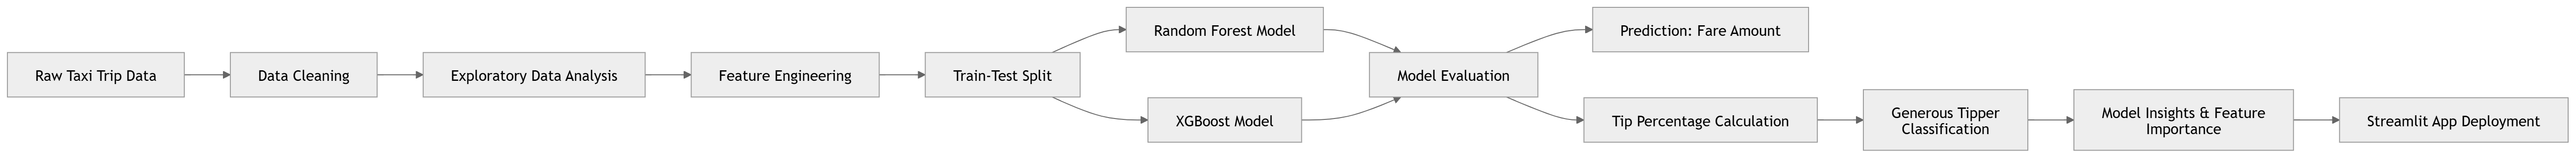

## *Milestone-1* [Plan]

## PACE Strategy Document
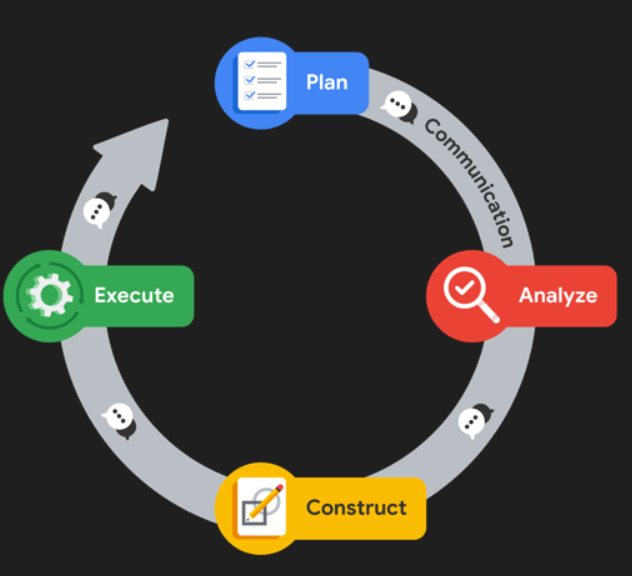

#### Data Project Questions & Considerations:
- PACE: Plan Stage:

1. Who is the audience for this project?
   - The primary audience is the New York City Taxi and Limousine Commission (TLC), which regulates taxi services and fare policies in New York City.
2. What problem is this project trying to solve?
    - The project aims to develop a predictive model that estimates taxi fares before a ride begins, improving fare transparency for riders and providing pricing insights for regulators.
3. What key questions should be answered?
   - What is the quality and completeness of the taxi trip dataset?
   - Which variables most strongly influence taxi fares and tipping behavior?
   - Are there patterns or trends in trip characteristics that affect pricing?
   - How can potential bias or anomalies in the data be identified and addressed?
4. What resources are required to complete the project?
   - NYC Taxi trip dataset
   - Python environment (Jupyter Notebook / VS Code)
   - Data analysis libraries (Pandas, NumPy, Scikit-learn)
   - Visualization tools (Matplotlib, Seaborn)
   - Computing resources for model training and evaluation
5. What deliverables will be produced?
   - Cleaned dataset ready for analysis
   - Exploratory data analysis and visualizations
   - Feature engineering and statistical insights
   - Machine learning models with evaluation metrics
   - Documentation summarizing methodology, results, and insights

## *_Milestone 2_* [Analyze]

### _1.0: Import Libraries:_

In [63]:
# import libraries

# For Mathematical Calculations
import pandas as pd
import numpy as np

# For Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# For Date and Time Manipulation
from datetime import datetime, timedelta

# For Statistical Analysis
from scipy import stats
from scipy.stats import norm, skew, boxcox

# ML
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from xgboost import XGBRegressor, XGBClassifier

### _1.1-Import The Data:_

In [64]:
df_automati = pd.read_csv('2017_Yellow_Taxi_Trip_Data.csv')

df = df_automati.copy()

### _2-Data Exploration:_
_2.0 Explore Dataset:_

In [65]:
df.head()

,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
0,24870114,2,03/25/2017 8:55:43 AM,03/25/2017 9:09:47 AM,6,3.34,1,N,100,231,1,13.0,0.0,0.5,2.76,0.0,0.3,16.56
1,35634249,1,04/11/2017 2:53:28 PM,04/11/2017 3:19:58 PM,1,1.80,1,N,186,43,1,16.0,0.0,0.5,4.00,0.0,0.3,20.80
2,106203690,1,12/15/2017 7:26:56 AM,12/15/2017 7:34:08 AM,1,1.00,1,N,262,236,1,6.5,0.0,0.5,1.45,0.0,0.3,8.75
3,38942136,2,05/07/2017 1:17:59 PM,05/07/2017 1:48:14 PM,1,3.70,1,N,188,97,1,20.5,0.0,0.5,6.39,0.0,0.3,27.69
4,30841670,2,04/15/2017 11:32:20 PM,04/15/2017 11:49:03 PM,1,4.37,1,N,4,112,2,16.5,0.5,0.5,0.00,0.0,0.3,17.80


In [66]:
df.info()

# there's no missing values in the dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22699 entries, 0 to 22698
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             22699 non-null  int64  
 1   VendorID               22699 non-null  int64  
 2   tpep_pickup_datetime   22699 non-null  object 
 3   tpep_dropoff_datetime  22699 non-null  object 
 4   passenger_count        22699 non-null  int64  
 5   trip_distance          22699 non-null  float64
 6   RatecodeID             22699 non-null  int64  
 7   store_and_fwd_flag     22699 non-null  object 
 8   PULocationID           22699 non-null  int64  
 9   DOLocationID           22699 non-null  int64  
 10  payment_type           22699 non-null  int64  
 11  fare_amount            22699 non-null  float64
 12  extra                  22699 non-null  float64
 13  mta_tax                22699 non-null  float64
 14  tip_amount             22699 non-null  float64
 15  to

In [67]:
df.describe()

,Unnamed: 0,VendorID,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
count,2.269900e+04,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000
mean,5.675849e+07,1.556236,1.642319,2.913313,1.043394,162.412353,161.527997,1.336887,13.026629,0.333275,0.497445,1.835781,0.312542,0.299551,16.310502
std,3.274493e+07,0.496838,1.285231,3.653171,0.708391,66.633373,70.139691,0.496211,13.243791,0.463097,0.039465,2.800626,1.399212,0.015673,16.097295
min,1.212700e+04,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,-120.000000,-1.000000,-0.500000,0.000000,0.000000,-0.300000,-120.300000
25%,2.852056e+07,1.000000,1.000000,0.990000,1.000000,114.000000,112.000000,1.000000,6.500000,0.000000,0.500000,0.000000,0.000000,0.300000,8.750000
50%,5.673150e+07,2.000000,1.000000,1.610000,1.000000,162.000000,162.000000,1.000000,9.500000,0.000000,0.500000,1.350000,0.000000,0.300000,11.800000
75%,8.537452e+07,2.000000,2.000000,3.060000,1.000000,233.000000,233.000000,2.000000,14.500000,0.500000,0.500000,2.450000,0.000000,0.300000,17.800000
max,1.134863e+08,2.000000,6.000000,33.960000,99.000000,265.000000,265.000000,4.000000,999.990000,4.500000,0.500000,200.000000,19.100000,0.300000,1200.290000


In [68]:
df.isnull().sum()

Unnamed: 0               0
VendorID                 0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
RatecodeID               0
store_and_fwd_flag       0
PULocationID             0
DOLocationID             0
payment_type             0
fare_amount              0
extra                    0
mta_tax                  0
tip_amount               0
tolls_amount             0
improvement_surcharge    0
total_amount             0
dtype: int64

In [69]:
df.duplicated().sum()

np.int64(0)

In [70]:
corr = df[['trip_distance', 'fare_amount']].corr()
desc = df[['trip_distance', 'fare_amount']].describe()
print(corr) 

print(desc)

               trip_distance  fare_amount
trip_distance       1.000000     0.756599
fare_amount         0.756599     1.000000
       trip_distance   fare_amount
count   22699.000000  22699.000000
mean        2.913313     13.026629
std         3.653171     13.243791
min         0.000000   -120.000000
25%         0.990000      6.500000
50%         1.610000      9.500000
75%         3.060000     14.500000
max        33.960000    999.990000


In [71]:
df[
    ['trip_distance', 'fare_amount']
    ].sort_values(by='fare_amount'
                  , ascending=False).head(10)

,trip_distance,fare_amount
8476,2.60,999.99
20312,0.00,450.00
13861,33.92,200.01
15474,0.00,200.00
12511,0.00,175.00
3582,7.30,152.00
9280,33.96,150.00
16379,25.50,140.00
10291,31.95,131.00
1928,12.50,120.00


#### _Project Status:_
- Explored dataset to find any unusual values.
- Considered which variables are most useful to build predictive models (in this case: total_amount and trip_distance, which work together to depict a taxi cab ride).
- Considered potential interactions between the two chosen variables.
- Examined which components of the provided data will provide relevant insights. 
- Built the groundwork for future exploratory data analysis, visualizations, and models. 

#### _Key Insights:_
- This dataset includes variables that should be helpful for building prediction model on taxi cab ride fares. 
- The identified unusual values are trips that are a short distance but have high charges associated with them, as shown in the total_amount variable.

#### _Next Steps:_
1. Conduct a complete EDA.
2. Perform any data cleaning and data analysis steps to understand unusual variables (e.g. Outliers).
3. Use descriptive statistics to learn more about the data.
4. Create and run a regression model.

## Milestone 3 Plan and Analyze:

#### _Exploratory Data Analysis:_

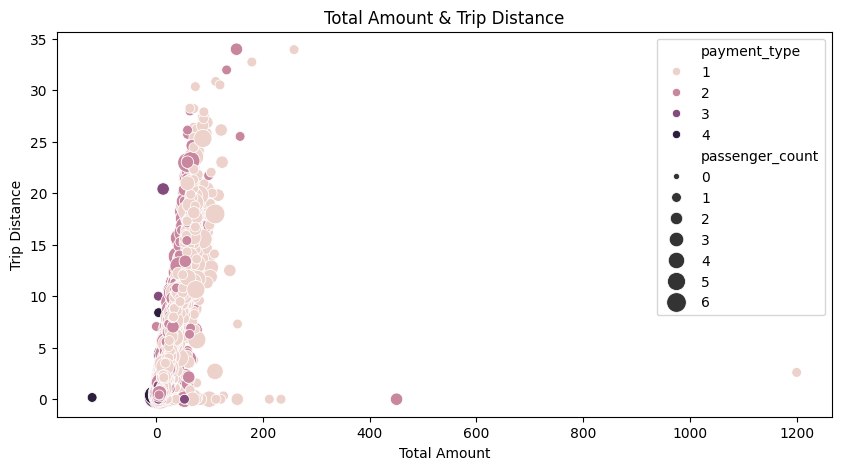

In [72]:
plt.figure(figsize=(10,5))
ax = sns.scatterplot(x='total_amount', y='trip_distance', data=df, hue='payment_type', size='passenger_count', sizes=(20, 200), legend= 'full')
plt.xlabel('Total Amount')
plt.ylabel('Trip Distance')
plt.title('Total Amount & Trip Distance')
plt.show()

#### _Key Insights:_
    The Problem: After running initial exploratory data analysis (EDA) the data provided by New York City TLC, it is clear that some of the data will prove an obstacle for accuarate ride fare prediction. Namely, trips that have a total cost entered, but a total distance of "0". At this point, our analysis indicates these to be anomalies or outliers that need to be factored into the algorthim or removed completely. 

    Proposed Solution: After analysis, we recommend removing outliers with a total distanced recorded of 0. 

#### _Next Steps:_
* Determine any unusual data points that could pose a problem for future analysis in predicting trip fares. 
* For example, locations that have longer durations.
* Determine the variables that have the largest impact on trip fares. 
* Filter down to consider the most relevant variables for running regression, statistical analysis, and parameter turning. 

### 3. Statistical Review and A/B Testing:


In [73]:
payment_counts = df['payment_type'].value_counts()

print(payment_counts)

payment_type
1    15265
2     7267
3      121
4       46
Name: count, dtype: int64


According to the data dictionary, the payment method was encoded as follows:

1. = Credit card
2. = Cash
3. = No charge
4. = Dispute
5. = Unknown
6. = Voided trip

In [74]:
# Ensure fare_amount is numeric
df['fare_amount'] = pd.to_numeric(df['fare_amount'], errors='coerce')

# Group by payment type and calculate descriptive statistics
descriptive_stats = df.groupby('payment_type')['fare_amount'].describe()
print(descriptive_stats)

                count       mean        std    min  25%  50%     75%     max
payment_type                                                                
1             15265.0  13.429748  13.848964    0.0  7.0  9.5  15.000  999.99
2              7267.0  12.213546  11.689940    0.0  6.0  9.0  14.000  450.00
3               121.0  12.186116  14.894232   -4.5  2.5  7.0  15.000   65.50
4                46.0   9.913043  24.162943 -120.0  5.0  8.5  17.625   52.00


#### Formulate Hypothesis:

* `Null Hypothesis (H0):` There is no significant difference in average total fare amount between customers using credit cards and those using cash.
* `Alternative Hypothesis (H1)`: There is a significant difference in average total fare amount between the two payment types.

#### Conduct a Two-Sample T-Test:
* Perform a two-sample t-test to compare the means of the two groups. This test will indicate whether any observed differences are statistically significant.
* Ensure assumptions of normality and equal variance are met, or consider using a non-parametric test, such as the Mann-Whitney U test, if needed.

In [75]:
t_stat, p_value = stats.ttest_ind(df[df['payment_type'] == 'credit_card']['fare_amount'], 
                                   df[df['payment_type'] == 'cash']['fare_amount'], 
                                   equal_var=False)
print(f"T-Statistic: {t_stat}, P-Value: {p_value}")

T-Statistic: nan, P-Value: nan


C:\Users\DELL\AppData\Local\Temp\ipykernel_22684\2491521933.py:1: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  t_stat, p_value = stats.ttest_ind(df[df['payment_type'] == 'credit_card']['fare_amount'],


In [76]:
credit_card_trips = df[df['payment_type'] == 1]

average_tip = credit_card_trips['tip_amount'].mean()

print(f"The average tip for trips paid with a credit card is: {average_tip:.2f}")

Cash_trips = df[df['payment_type'] == '2']

average_Cash_tip = Cash_trips['tip_amount'].mean()

print(f"The average tip for trips paid with Cash is: {average_tip:.2f}")

The average tip for trips paid with a credit card is: 2.73
The average tip for trips paid with Cash is: 2.73


In [77]:
mean_total_amount = df.groupby('VendorID')['total_amount'].mean().reset_index()

print(mean_total_amount)

   VendorID  total_amount
0         1     16.298119
1         2     16.320382


In [78]:
credit_card_payments = df[df['payment_type'] == 1]

print(credit_card_payments)

credit_card_payments = df[df['payment_type'] == 1]

passenger_count_data = credit_card_payments[['passenger_count']]

print(passenger_count_data)

       Unnamed: 0  VendorID    tpep_pickup_datetime   tpep_dropoff_datetime  \
0        24870114         2   03/25/2017 8:55:43 AM   03/25/2017 9:09:47 AM   
1        35634249         1   04/11/2017 2:53:28 PM   04/11/2017 3:19:58 PM   
2       106203690         1   12/15/2017 7:26:56 AM   12/15/2017 7:34:08 AM   
3        38942136         2   05/07/2017 1:17:59 PM   05/07/2017 1:48:14 PM   
5        23345809         2   03/25/2017 8:34:11 PM   03/25/2017 8:42:11 PM   
...           ...       ...                     ...                     ...   
22692    60425673         1   07/16/2017 3:22:51 AM   07/16/2017 3:40:52 AM   
22693    67858616         2  08/10/2017 10:20:04 PM  08/10/2017 10:29:31 PM   
22695    66632549         2   08/06/2017 4:43:59 PM   08/06/2017 5:24:47 PM   
22697    60217333         2  07/15/2017 12:56:30 PM   07/15/2017 1:08:26 PM   
22698    17208911         1   03/02/2017 1:02:49 PM   03/02/2017 1:16:09 PM   

       passenger_count  trip_distance  RatecodeID s

In [79]:
credit_card_payments = df[df['payment_type'] == 1]

average_tip_per_passenger_count = credit_card_payments.groupby('passenger_count')['tip_amount'].mean().reset_index()

print(average_tip_per_passenger_count)

   passenger_count  tip_amount
0                0    2.610370
1                1    2.714681
2                2    2.829949
3                3    2.726800
4                4    2.607753
5                5    2.762645
6                6    2.643326


### _Statistical Review And A/B Testing:_

#### _Problem:_
    Taxi cab drivers recieve varying amount of tips. While examining the relationship between total fare amount and payment type, this project seeks to discover if customers who pay in credit card tend to pay a larger total fare amount than customers who pay in cash. 

#### _Solution:_
    The Automatidata team ran an A/B test to analyze the relationships between credit card payment and total fare amount. The key business insight is that encouraging customers to pay with credit cards will likely generate more revenue for taxi drvers. 

#### _Details:_
`Steps Conducted in the A/B Test:`
1. Collected sample data from an experiment in which customers are randomly selected and divide into two groups:
   * Customers who are required to pay with credit card. 
   * Customers who are required to pay with cash. This enables us to draw casual conculsions about how payment method affects fare amount. 
2. Computed descriptive statistics to better understand the average total fare maount for each payment method available to the customer. 
3. Conducted a two-sample t-test to determine if there is a statistically significant difference in average total fare between customers who use credit cards and customers who use cash. 

#### _A/B Test Results:_
    There is a statisitically significant difference in the average total fare between customers who use credit cards and customers who use cash. Customers who sued credit cards showed a higher total amount comapre to cash. 

#### _Next Steps:_
    The NYC TLC encourages customers to pay with credit cards, and create strategies to promote credit card payments. For example, the NYC TLC can install signs that read "Credit card payment are preferred" in their cabs, and implement a protocal that requires cab drivers to verbally inform customers that credit card payment are preferred. 

### Feature Enginnering:

### Model Development & Comparison

#### Problem: 
- `The initial modeling objective (predicting non-tippers) out of ethical concern, it was decided to predict "generous" tippers-those who tip >=20%. This decision was made to balance the sometimes competing interest taxi drivers and potential passengers.`

### Solution:
- `I would recommend using this model as a tool to derive deeper business insight, or at best a very rough guide to taxi drivers.`

### Details:
Behind the data:
- `That a trip's itinerary predicted fare amount and time of day may have a strong enough relationship with tip amount that could accuarately predict generaous tipping.`
- `After built the identifies models and performed the testing, it became clear that there was not as strong a correlation as anticipated, with an F1 score of just 0.350 `
  
### Result Summary:
- `The resulting algorithm is usable to predict riders who might be generous tippers, but has serious limitations to its usability business decisions.`

In [80]:
df['pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])

df['hour'] = df['pickup_datetime'].dt.hour
df['day_of_week'] = df['pickup_datetime'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].isin([5,6]).astype(int)

In [81]:
# Create Tip Percentage & Generous Label

df['tip_percent'] = (df['tip_amount'] / df['fare_amount']) * 100

# Define generous tipper (20% threshold)
df['generous'] = (df['tip_percent'] >= 20).astype(int)

In [82]:
# Select Features
features = [
    'trip_distance',
    'passenger_count',
    'hour',
    'day_of_week',
    'is_weekend'
]

X = df[features]

In [83]:
# PART A — FARE PREDICTION (Regression)

# Define Target
y_fare = df['fare_amount']

In [84]:
# Train-Test Split
x_train_fare, x_test_fare, y_train_fare, y_test_fare = train_test_split(X, y_fare, test_size=0.2, random_state=42)

In [85]:
#Train Random Forest Regressor
rf_reg = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_reg.fit(x_train_fare, y_train_fare)

y_pred_rf = rf_reg.predict(x_test_fare)

In [106]:
# Evaluate Regression

rmse = np.sqrt(mean_squared_error(y_test_fare, y_pred_rf))
mae = mean_absolute_error(y_test_fare, y_pred_rf)
r2 = r2_score(y_test_fare, y_pred_rf)

print("Random Forest Regression Results")
print("Root Mean Squared Error (RMSE):", rmse)
print("Mean Absolute Error (MAE):", mae)
print("R-squared (R2):", r2)

Random Forest Regression Results
Root Mean Squared Error (RMSE): 15.511750854328433
Mean Absolute Error (MAE): 2.1364948120050533
R-squared (R2): 0.2691748802786106


In [87]:
# Train XGBoost Regressor

xgb_reg = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)

xgb_reg.fit(x_train_fare, y_train_fare)

y_pred_xgb = xgb_reg.predict(x_test_fare)

rmse_xgb = np.sqrt(mean_squared_error(y_test_fare, y_pred_xgb))
print("XGBoost RMSE:", rmse_xgb)

XGBoost RMSE: 16.44085418237795


In [88]:
# GENEROUS TIPPER PREDICTION (Classification)

# Define Target
y_generous = df['generous']

In [89]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_generous, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_generous
)

In [90]:
# Train Random Forest Classifier

rf_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_clf.fit(X_train_c, y_train_c)

y_pred_rf_c = rf_clf.predict(X_test_c)

In [91]:
# Evaluate Classification

print("Random Forest Classification Results")
print("Accuracy:", accuracy_score(y_test_c, y_pred_rf_c))
print("ROC AUC:", roc_auc_score(y_test_c, rf_clf.predict_proba(X_test_c)[:,1]))
print(classification_report(y_test_c, y_pred_rf_c))

Random Forest Classification Results
Accuracy: 0.5259911894273128
ROC AUC: 0.5371057105093128
              precision    recall  f1-score   support

           0       0.53      0.60      0.56      2316
           1       0.52      0.45      0.48      2224

    accuracy                           0.53      4540
   macro avg       0.53      0.52      0.52      4540
weighted avg       0.53      0.53      0.52      4540



In [92]:
# Train XGBoost Classifier

xgb_clf = XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

xgb_clf.fit(X_train_c, y_train_c)

y_pred_xgb_c = xgb_clf.predict(X_test_c)

print("XGBoost Accuracy:", accuracy_score(y_test_c, y_pred_xgb_c))
print("XGBoost ROC AUC:", roc_auc_score(y_test_c, xgb_clf.predict_proba(X_test_c)[:,1]))

c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [14:12:26] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 0.5222466960352423
XGBoost ROC AUC: 0.525584260570818


In [94]:
# Feature Importance for Regression

importances = rf_reg.feature_importances_

for f, imp in zip(features, importances):
    print(f"{f}: {imp:.4f}")

trip_distance: 0.8623
passenger_count: 0.0349
hour: 0.0707
day_of_week: 0.0288
is_weekend: 0.0033


Advanced Feature Engineering

In [95]:
df.columns

Index(['Unnamed: 0', 'VendorID', 'tpep_pickup_datetime',
       'tpep_dropoff_datetime', 'passenger_count', 'trip_distance',
       'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID',
       'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount',
       'tolls_amount', 'improvement_surcharge', 'total_amount',
       'pickup_datetime', 'hour', 'day_of_week', 'is_weekend', 'tip_percent',
       'generous'],
      dtype='object')

In [96]:
# Create Trip Duration

df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])

df['trip_duration'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60


In [97]:
# Create Average Speed
df['avg_speed'] = df['trip_distance'] / (df['trip_duration'] / 60)

#This helps detect:

# traffic conditions

# abnormal trips

In [98]:
# Create Tip Percentage
df['tip_percentage'] = (df['tip_amount'] / df['fare_amount']) * 100

In [99]:
# Time-Based Features
df['pickup_hour'] = df['pickup_datetime'].dt.hour
df['pickup_day'] = df['pickup_datetime'].dt.dayofweek
df['pickup_month'] = df['pickup_datetime'].dt.month

These capture behavior patterns.

Example:
- Night trips may tip more
- Weekend trips differ

<Axes: xlabel='trip_distance', ylabel='fare_amount'>

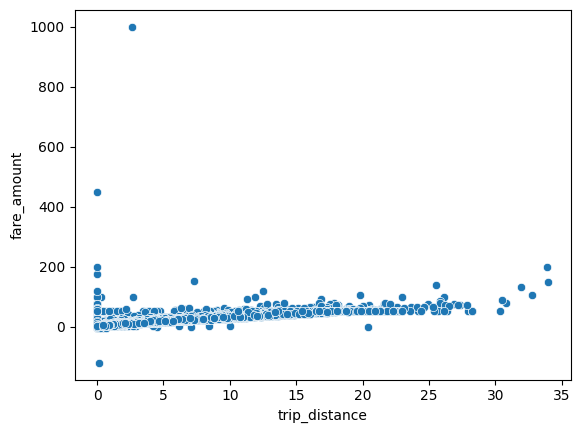

In [100]:
# Advanced Visualizations

# Fare vs Distance
import seaborn as sns

sns.scatterplot(x='trip_distance', y='fare_amount', data=df)

<Axes: xlabel='pickup_hour', ylabel='tip_percentage'>

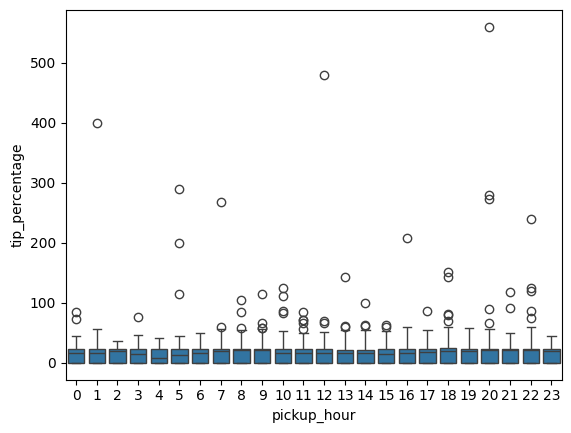

In [101]:
# Tip Behavior by Hour
sns.boxplot(x='pickup_hour', y='tip_percentage', data=df)

# Shows tipping patterns over time.

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

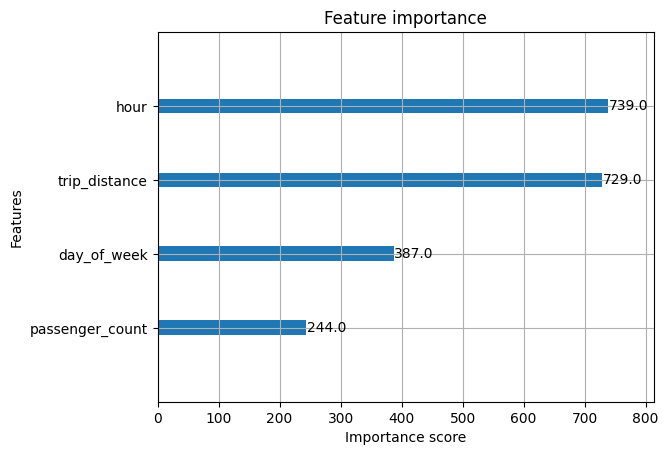

In [110]:
# Feature Importance Visualization

import xgboost as xgb

xgb.plot_importance(best_model)